### Examples for SelectKBest and Fisher Score

These tools can be used to determine the most optimal variables in your dataset (or redundant ones)

In [1]:
import pandas as pd

# load the data
df = pd.read_csv("../houses_fixed.csv")

# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['id', 'date', 'zipcode', 'lat', 'long'], axis=1)

# take smaller sample since Fisher score is otherwise too heavy to calculate
df = df.sample(7500)

# perform X/y -split
# if you  have more than one independent variable, list them all here
# leave out the target variable! (dependent variable)

# this is a nice and common trick => everything EXCEPT target variable => support variable
X = df.drop("price", axis=1)

# have only the target variable here (dependent variable)
y = df["price"]

### Fisher score can be super slow with large datasets, you might want to take a smaller sample before attempting it!

<Axes: >

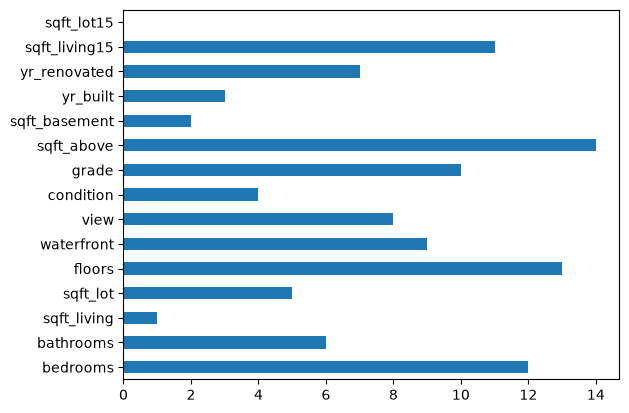

In [ ]:
# Fisher score to important variables in the dataset
# pip install skfeature-chappers
from skfeature.function.similarity_based import fisher_score

# get the fisher's score rankings 
ranks = fisher_score.fisher_score(X.values, y.values)

# create a pandas DataFrame for easier interpretation
feat_importances = pd.Series(ranks, X.columns)
feat_importances.plot(kind='barh')

# how to interpret -> low score means the effect of this field is not large in the dataset
# => typically means other columns in the dataset have similar correlations/connections, 
# therefore making this particular column not so useful since other columns 
# already fill this role for this correlation

# Fisher's score studies the variance of the data -> statistical significance